## Import Libraries

In [2]:
import os
import random
import warnings
import logging

import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    set_seed
)

from peft import LoraConfig, get_peft_model, TaskType

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

from transformers.utils.notebook import NotebookProgressCallback

import warnings
warnings.filterwarnings("ignore")

from transformers import logging
logging.set_verbosity_error()

### Device

In [3]:
SEED = 42
set_seed(SEED)

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print("Device:", device)

Device: mps


## Read Data

In [4]:
DATA_PATH = "../data/"

train = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
val = pd.read_csv(os.path.join(DATA_PATH, "val.csv"))
test = pd.read_csv(os.path.join(DATA_PATH, "test.csv"))

print("Train:", train.shape)
print("Validation:", val.shape)
print("Test:", test.shape)

train.head()

Train: (11528, 2)
Validation: (1442, 2)
Test: (1442, 2)


,comment,labels
0,"Я честно хз, но у меня есть подозрение, что тр...",0
1,"Ну зашибись. Мне гланды удалили, остаётся полз...",0
2,Это когда спрос равен предложению. Если повыша...,0
3,"Ужас, только вчера думала о том, а что, если в...",0
4,"Кроме того, в комплектацию входят прибор ночно...",0


## Prepare Hugging Face Datasets

In [5]:
train_ds = Dataset.from_pandas(
    train[["comment", "labels"]],
    preserve_index=False
)

val_ds = Dataset.from_pandas(
    val[["comment", "labels"]],
    preserve_index=False
)

test_ds = Dataset.from_pandas(
    test[["comment", "labels"]],
    preserve_index=False
)

train_ds

Dataset({
    features: ['comment', 'labels'],
    num_rows: 11528
})

## Tokenization

In [6]:
MODEL_NAME = "DeepPavlov/rubert-base-cased-conversational"
MAX_LENGTH = 256
NUM_LABELS = 2

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["comment"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

train_ds = train_ds.map(tokenize, batched=True)
val_ds = val_ds.map(tokenize, batched=True)
test_ds = test_ds.map(tokenize, batched=True)

Map:   0%|          | 0/11528 [00:00<?, ? examples/s]

Map:   0%|          | 0/1442 [00:00<?, ? examples/s]

Map:   0%|          | 0/1442 [00:00<?, ? examples/s]

## Dataset Formatting

In [7]:
columns = ["input_ids", "attention_mask", "labels"]

train_ds.set_format("torch", columns=columns)
val_ds.set_format("torch", columns=columns)
test_ds.set_format("torch", columns=columns)

## Load base model

In [8]:
base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

## LoRA Configuration

In [11]:
import math

num_train_epochs = 4
per_device_train_batch_size = 2
gradient_accumulation_steps = 8

steps_per_epoch = math.ceil(
    len(train_ds) / (per_device_train_batch_size * gradient_accumulation_steps)
)

total_steps = steps_per_epoch * num_train_epochs

print("Steps per epoch:", steps_per_epoch)
print("Total steps:", total_steps)

Steps per epoch: 721
Total steps: 2884


In [13]:
from peft import AdaLoraConfig, get_peft_model, TaskType

adalora_config = AdaLoraConfig(
    task_type=TaskType.SEQ_CLS,

    init_r=32,
    target_r=16,
    beta1=0.85,
    beta2=0.85,
    tinit=200,
    tfinal=1000,
    deltaT=10,
    total_step=total_steps,

    lora_alpha=64,
    lora_dropout=0.05,

    target_modules=["query", "key", "value", "dense"],
    modules_to_save=["classifier"]
)

model = get_peft_model(base_model, adalora_config)
model.print_trainable_parameters()

trainable params: 10,719,010 || all params: 188,574,061 || trainable%: 5.6842


## Define Evaluation Metrics

In [14]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0)
    }

## Training Configuration

In [15]:
training_args = TrainingArguments(
    output_dir="./rubert_base_adalora",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,
    num_train_epochs=4,

    per_device_train_batch_size=2,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=8,

    weight_decay=0.01,

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    logging_strategy="steps",
    logging_steps=50,
    disable_tqdm=False,

    report_to="none",
    dataloader_pin_memory=False,

    seed=SEED
)

## Trainer Initialization

In [16]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics
)

## Model Training

In [17]:
train_result = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Macro F1
1,13.371013,1.630006,0.911234,0.875264,0.857143,0.866109,0.899859
2,10.173118,1.236552,0.914008,0.843212,0.913043,0.876740,0.905356
3,9.344142,1.192348,0.919556,0.883090,0.875776,0.879418,0.909532
4,9.461136,1.194697,0.920250,0.881743,0.879917,0.880829,0.910451


In [18]:
trainer.remove_callback(NotebookProgressCallback)

## Threshold

In [19]:
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np
from scipy.special import softmax

val_outputs = trainer.predict(val_ds)

val_probs = softmax(val_outputs.predictions, axis=1)[:, 1]
val_labels = val_outputs.label_ids

best_threshold = 0.5
best_f1 = 0

for threshold in np.arange(0.1, 0.9, 0.01):
    val_preds = (val_probs >= threshold).astype(int)

    f1 = f1_score(val_labels, val_preds)
    precision = precision_score(val_labels, val_preds)
    recall = recall_score(val_labels, val_preds)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold
        best_precision = precision
        best_recall = recall

print("Best threshold:", best_threshold)
print("Best validation toxic F1:", best_f1)
print("Precision:", best_precision)
print("Recall:", best_recall)

Best threshold: 0.18999999999999995
Best validation toxic F1: 0.8866995073891626
Precision: 0.8458646616541353
Recall: 0.9316770186335404


## Vaidation Evaluation

In [21]:
val_metrics = trainer.evaluate(val_ds)

for metric, value in val_metrics.items():
    print(f"{metric}: {value}")

eval_loss: 1.1946966648101807
eval_accuracy: 0.920249653259362
eval_precision: 0.8817427385892116
eval_recall: 0.8799171842650103
eval_f1: 0.8808290155440415
eval_macro_f1: 0.9104509851039644
eval_runtime: 28.3761
eval_samples_per_second: 50.817
eval_steps_per_second: 12.722
epoch: 4.0


## Test Evaluation

In [22]:
test_metrics = trainer.evaluate(test_ds)

for metric, value in test_metrics.items():
    print(f"{metric}: {value}")

eval_loss: 1.18868887424469
eval_accuracy: 0.9271844660194175
eval_precision: 0.89375
eval_recall: 0.8881987577639752
eval_f1: 0.8909657320872274
eval_macro_f1: 0.9181533501664664
eval_runtime: 28.2348
eval_samples_per_second: 51.072
eval_steps_per_second: 12.786
epoch: 4.0


## Predictions on Test Data

In [23]:
predictions = trainer.predict(test_ds)

preds = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

## Classification Report

In [24]:
print(
    classification_report(
        labels,
        preds,
        target_names=["non-toxic", "toxic"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

   non-toxic       0.94      0.95      0.95       959
       toxic       0.89      0.89      0.89       483

    accuracy                           0.93      1442
   macro avg       0.92      0.92      0.92      1442
weighted avg       0.93      0.93      0.93      1442



## Confusion Matrix

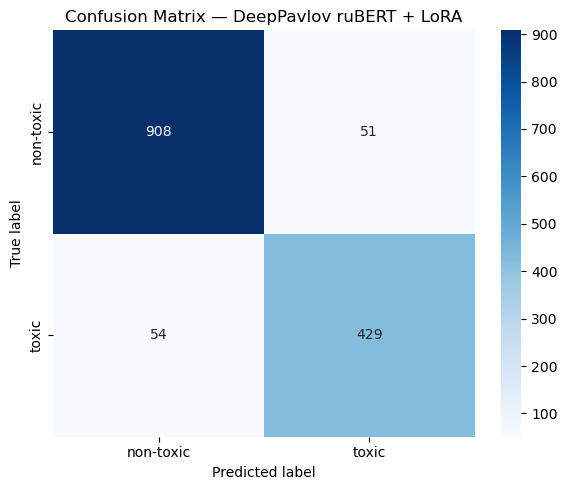

In [25]:
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["non-toxic", "toxic"],
    yticklabels=["non-toxic", "toxic"]
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix — DeepPavlov ruBERT + LoRA")
plt.tight_layout()
plt.show()

## Save model

In [26]:
SAVE_PATH = "../experiments/deep_pavlov_adalora"

model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

print(f"Model saved to: {SAVE_PATH}")

Model saved to: ../experiments/deep_pavlov_adalora


In [27]:
lora_results = {
    "model": "DeepPavlov ruBERT + adaLoRA",
    "base_model": MODEL_NAME,
    "lora_r": 16,
    "lora_alpha": 32,
    "lora_dropout": 0.05,
    "max_length": MAX_LENGTH,
    "test_accuracy": test_metrics["eval_accuracy"],
    "test_precision": test_metrics["eval_precision"],
    "test_recall": test_metrics["eval_recall"],
    "test_f1": test_metrics["eval_f1"],
    "test_macro_f1": test_metrics["eval_macro_f1"]
}

lora_results

{'model': 'DeepPavlov ruBERT + adaLoRA',
 'base_model': 'DeepPavlov/rubert-base-cased-conversational',
 'lora_r': 16,
 'lora_alpha': 32,
 'lora_dropout': 0.05,
 'max_length': 256,
 'test_accuracy': 0.9271844660194175,
 'test_precision': 0.89375,
 'test_recall': 0.8881987577639752,
 'test_f1': 0.8909657320872274,
 'test_macro_f1': 0.9181533501664664}